
# 04. 대조 실험: 처음부터 같이 배우기 vs 순서대로 키우기

규칙 세계 v1, 처음 보는 조합(composition), seed 42–45. 언어 부품은 mDeBERTa-NLI, 판단 부품은 출처 구조 판단기다.

- **같이 배우기**: 두 부품을 처음부터 최종 답만으로 함께 학습한다 (8에폭).
- **순서대로**: 읽기(4에폭, 단순 판단기와 함께) → 판단(언어 부품 고정, 8에폭) → 함께 다듬기(3에폭). 노트북 03과 같은 결과다.

질문: 순서대로 키우기가 나은 이유는 무엇인가? 더 높이 가서인가, 덜 실패해서인가?


In [1]:

import statistics
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = [42, 43, 44, 45]
joint = {s: S.interface_result("interface-anchored-learned-sourcefold", seed=s) for s in SEEDS}
staged = {s: S.interface_result("interface-anchored-learned-sourcefold-staged-tuned", seed=s) for s in SEEDS}



## 1. seed별 최종 점수


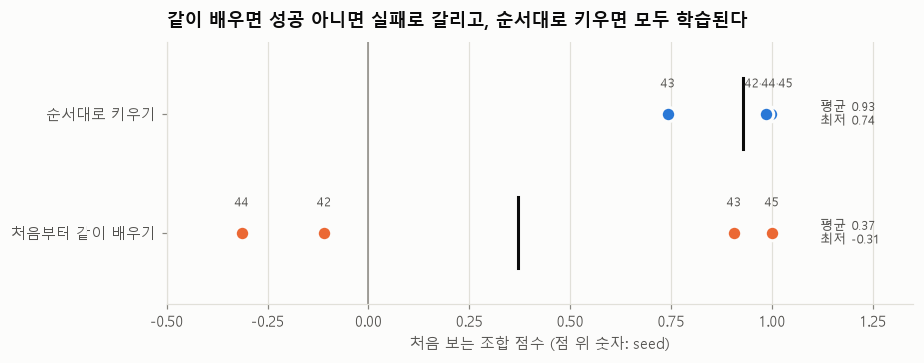

In [2]:

fig, ax = plt.subplots(figsize=(8.5, 3.4))
for i, (label, runs, color) in enumerate([("처음부터 같이 배우기", joint, V.ORANGE), ("순서대로 키우기", staged, V.BLUE)]):
    scores = [runs[s]["score"] for s in SEEDS]
    ax.scatter(scores, [i] * 4, s=90, color=color, edgecolor=V.SURFACE, linewidth=2, zorder=3)
    # Points closer than 0.06 are labeled once with all their seeds (e.g. "42·44·45").
    clusters = []
    for s_, score in sorted(zip(SEEDS, scores), key=lambda pair: pair[1]):
        if clusters and score - clusters[-1][-1][1] < 0.06:
            clusters[-1].append((s_, score))
        else:
            clusters.append([(s_, score)])
    for cluster in clusters:
        x = sum(score for _, score in cluster) / len(cluster)
        ax.text(x, i + 0.22, "·".join(str(s_) for s_, _ in sorted(cluster)), ha="center", fontsize=8,
                color=V.TEXT_SECONDARY)
    mean = statistics.mean(scores)
    ax.plot([mean, mean], [i - 0.3, i + 0.3], color=V.TEXT, linewidth=2)
    ax.text(1.12, i, f"평균 {mean:.2f}\n최저 {min(scores):.2f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.axvline(0, color=V.MUTED, linewidth=1)
ax.set_yticks([0, 1], ["처음부터 같이 배우기", "순서대로 키우기"])
ax.set_ylim(-0.6, 1.6)
ax.set_xlim(-0.5, 1.35)
ax.grid(axis="y", visible=False)
ax.set_xlabel("처음 보는 조합 점수 (점 위 숫자: seed)")
ax.set_title("같이 배우면 성공 아니면 실패로 갈리고, 순서대로 키우면 모두 학습된다", pad=10)
fig.tight_layout()
plt.show()



## 2. 학습 과정: 같이 배우기의 훈련 손실

손실 1.38은 정답 비율만 외운 상태다. seed 42는 이 수준에서 끝까지 머물렀고, 메시지 탐침도 찍기 수준(0.74)이었다. 메시지에 정보가 전혀 담기지 않은 것이다(의사소통이 생기지 않는 균형). seed 44는 1.05에서 멈췄다. 일부는 배웠지만(탐침 0.86) 시험 점수는 −0.31이다.


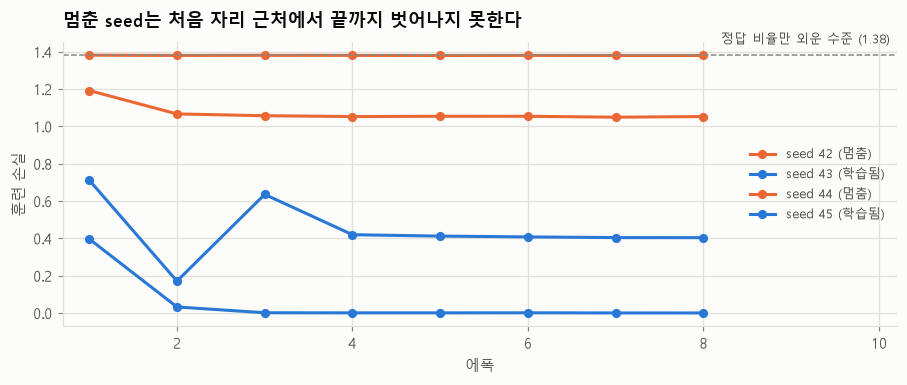

In [3]:

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for s in SEEDS:
    losses = joint[s]["train_loss"]
    stalled = min(losses) > 1.0
    ax.plot(range(1, len(losses) + 1), losses, "-o", markersize=5,
            color=V.ORANGE if stalled else V.BLUE, label=f"seed {s} ({'멈춤' if stalled else '학습됨'})")
ax.axhline(1.38, color=V.MUTED, linestyle="--", linewidth=1)
ax.text(8.2, 1.43, "정답 비율만 외운 수준 (1.38)", va="bottom", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xlim(0.7, 10.2)
ax.set_xlabel("에폭")
ax.set_ylabel("훈련 손실")
ax.set_title("멈춘 seed는 처음 자리 근처에서 끝까지 벗어나지 못한다", pad=10)
ax.legend(loc="center right", fontsize=8.5)
fig.tight_layout()
plt.show()



## 3. 정리

| | 처음부터 같이 | 순서대로 |
|---|---|---|
| 멈춘 seed | 2 / 4 (42, 44) | 0 / 4 |
| 평균 점수 | 0.37 | 0.93 |
| 최저 점수 | −0.31 | 0.74 |
| 최고 점수 | 1.00 | 0.999 |

- **순서대로 키우기의 장점은 안정성이다.** 같이 배우기는 잘되면 만점(seed 45)이지만, 절반은 의사소통이 생기지 않는 상태에서 빠져나오지 못했다. 순서대로 키우기는 모든 seed에서 학습되었다.
- 평균 차이(+0.56)는 크지만 seed마다 들쭉날쭉해서, seed 4개로는 신뢰구간이 0을 포함한다. "멈출 확률"을 확실히 비교하려면 seed가 더 필요하다.
- **반대 사례**: seed 43은 같이 배우기 0.91이 순서대로 키우기 0.74보다 높았다. 순서대로 키우면 1단계 읽기 부품의 약점("부정 하나뿐")을 그대로 물려받는다. 순서대로 키우기는 실패를 없애지만, 첫 단계의 실수를 고정시키는 위험이 있다.
- 처음 seed 42 하나만 보고 "같이 배우면 멈춘다"고 했던 것은 정정했다. seed 하나로 결론 내지 않는다는 원칙의 두 번째 사례다(첫 번째는 커리큘럼).
